In [1]:
import os.path
import anndata as ad
import mudata as md
import numpy as np
import pandas as pd
import mofaflex as mfl
from plotnine import *
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from umap import UMAP
from sklearn.manifold import TSNE

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



# Post mofa-flex analysis

In [2]:
models_path = Path("/g/stegle/aalsayah/repos/data/models_obj")

In [ ]:
#model= mfl.MOFAFLEX.load(models_path / 'crc_231.hdf5')

WARNING	The stored model was created with a different version of MOFA-FLEX. Some features may not work.


In [ ]:
#model = mfl.MOFAFLEX.load(models_path / "sns_models/crc_231_no_mye/Normal.SnS/crc_231_no_mye.Normal.SnS.hdf5")

WARNING	The stored model was created with a different version of MOFA-FLEX. Some features may not work.


In [3]:
model = mfl.MOFAFLEX.load(models_path / "GP_models/crc_231_no_mye/GP.Normal/crc_231_no_mye.GP.Normal.hdf5")

## Variance Explained

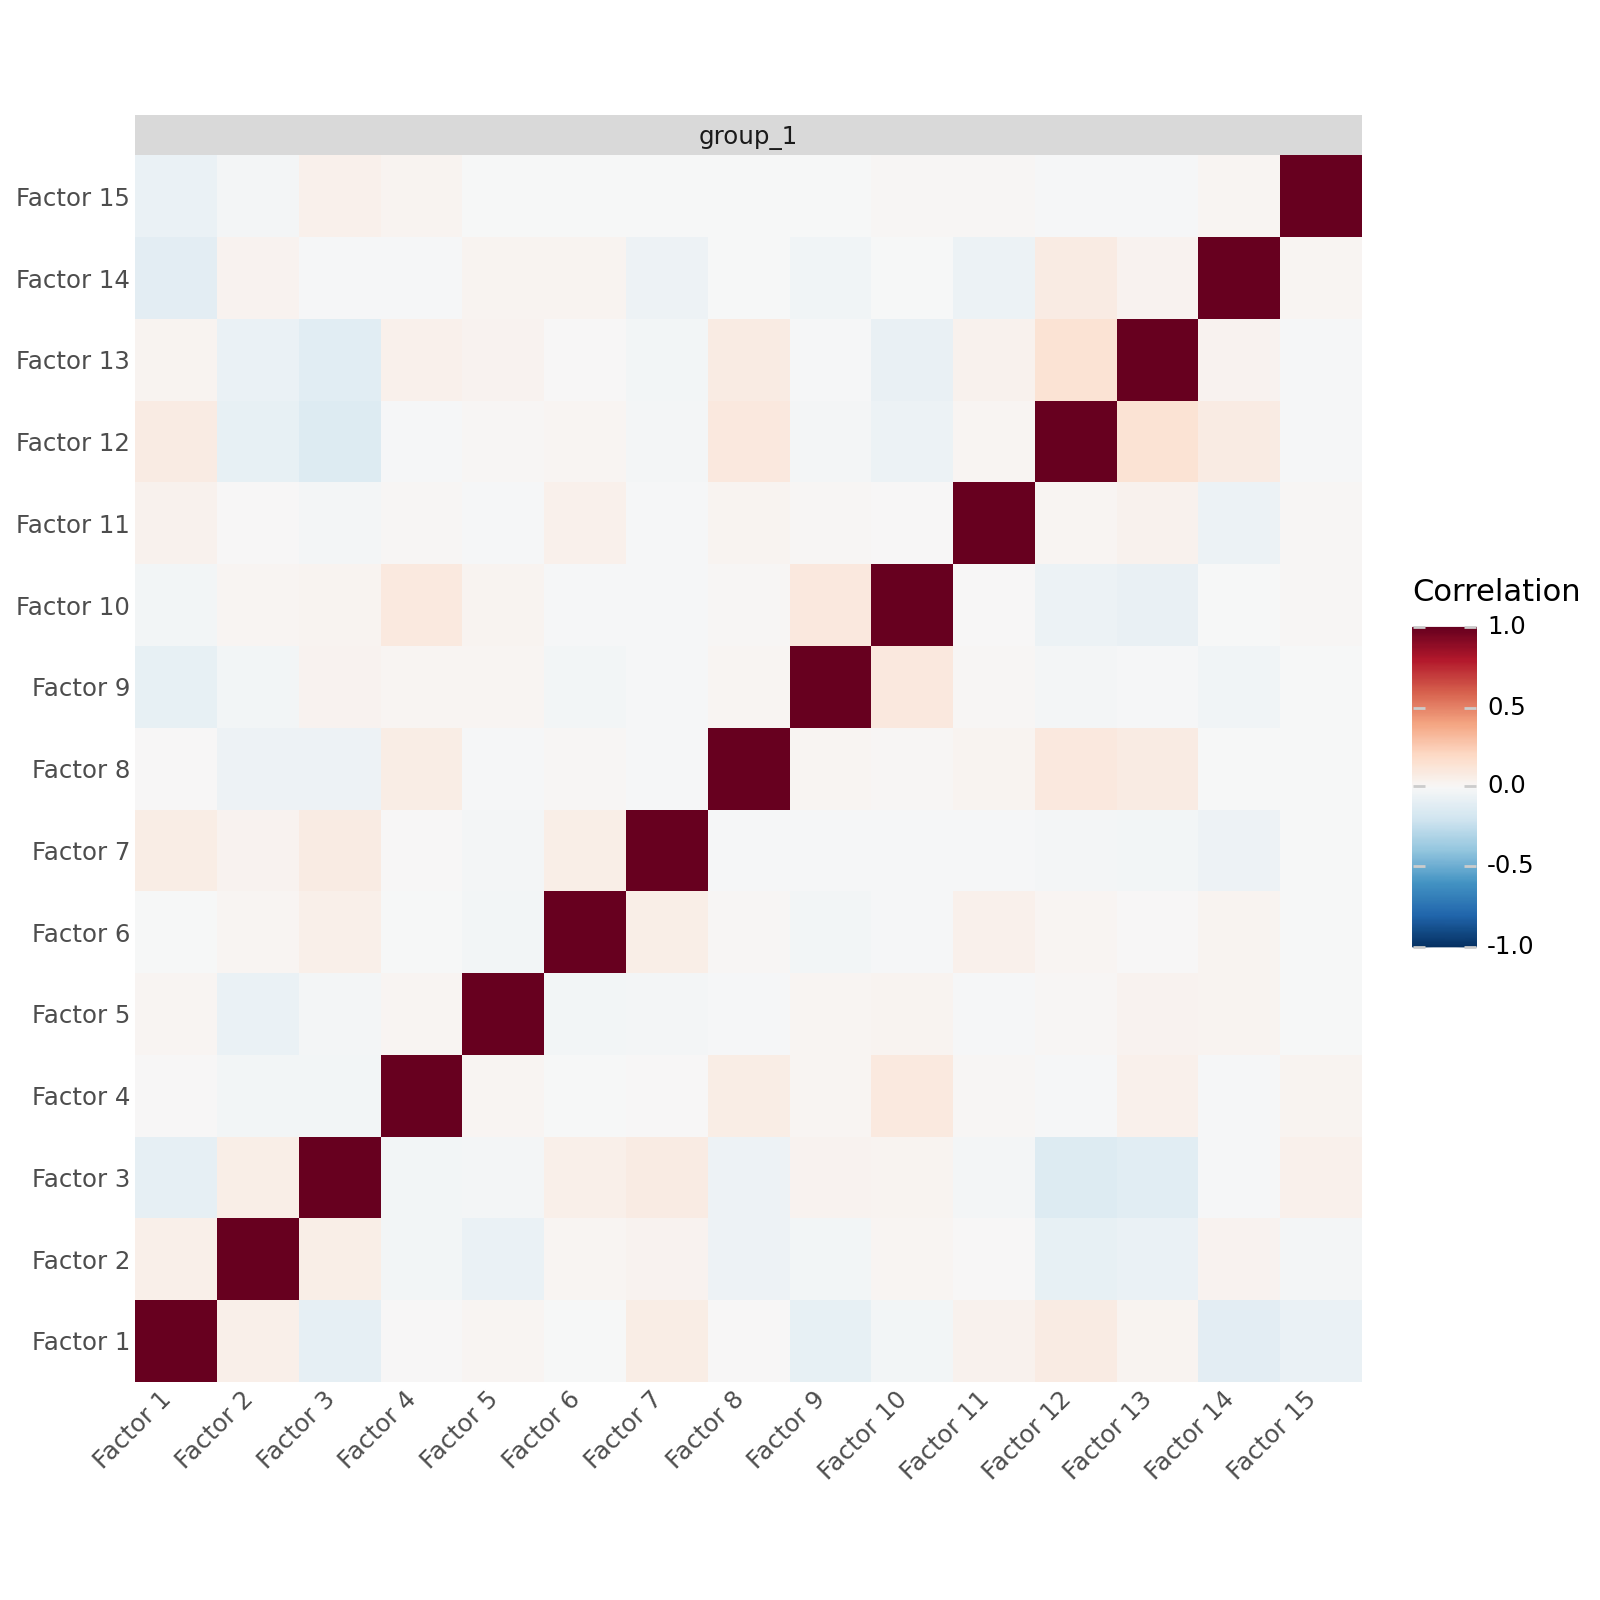

In [4]:
mfl.pl.factor_correlation(model)

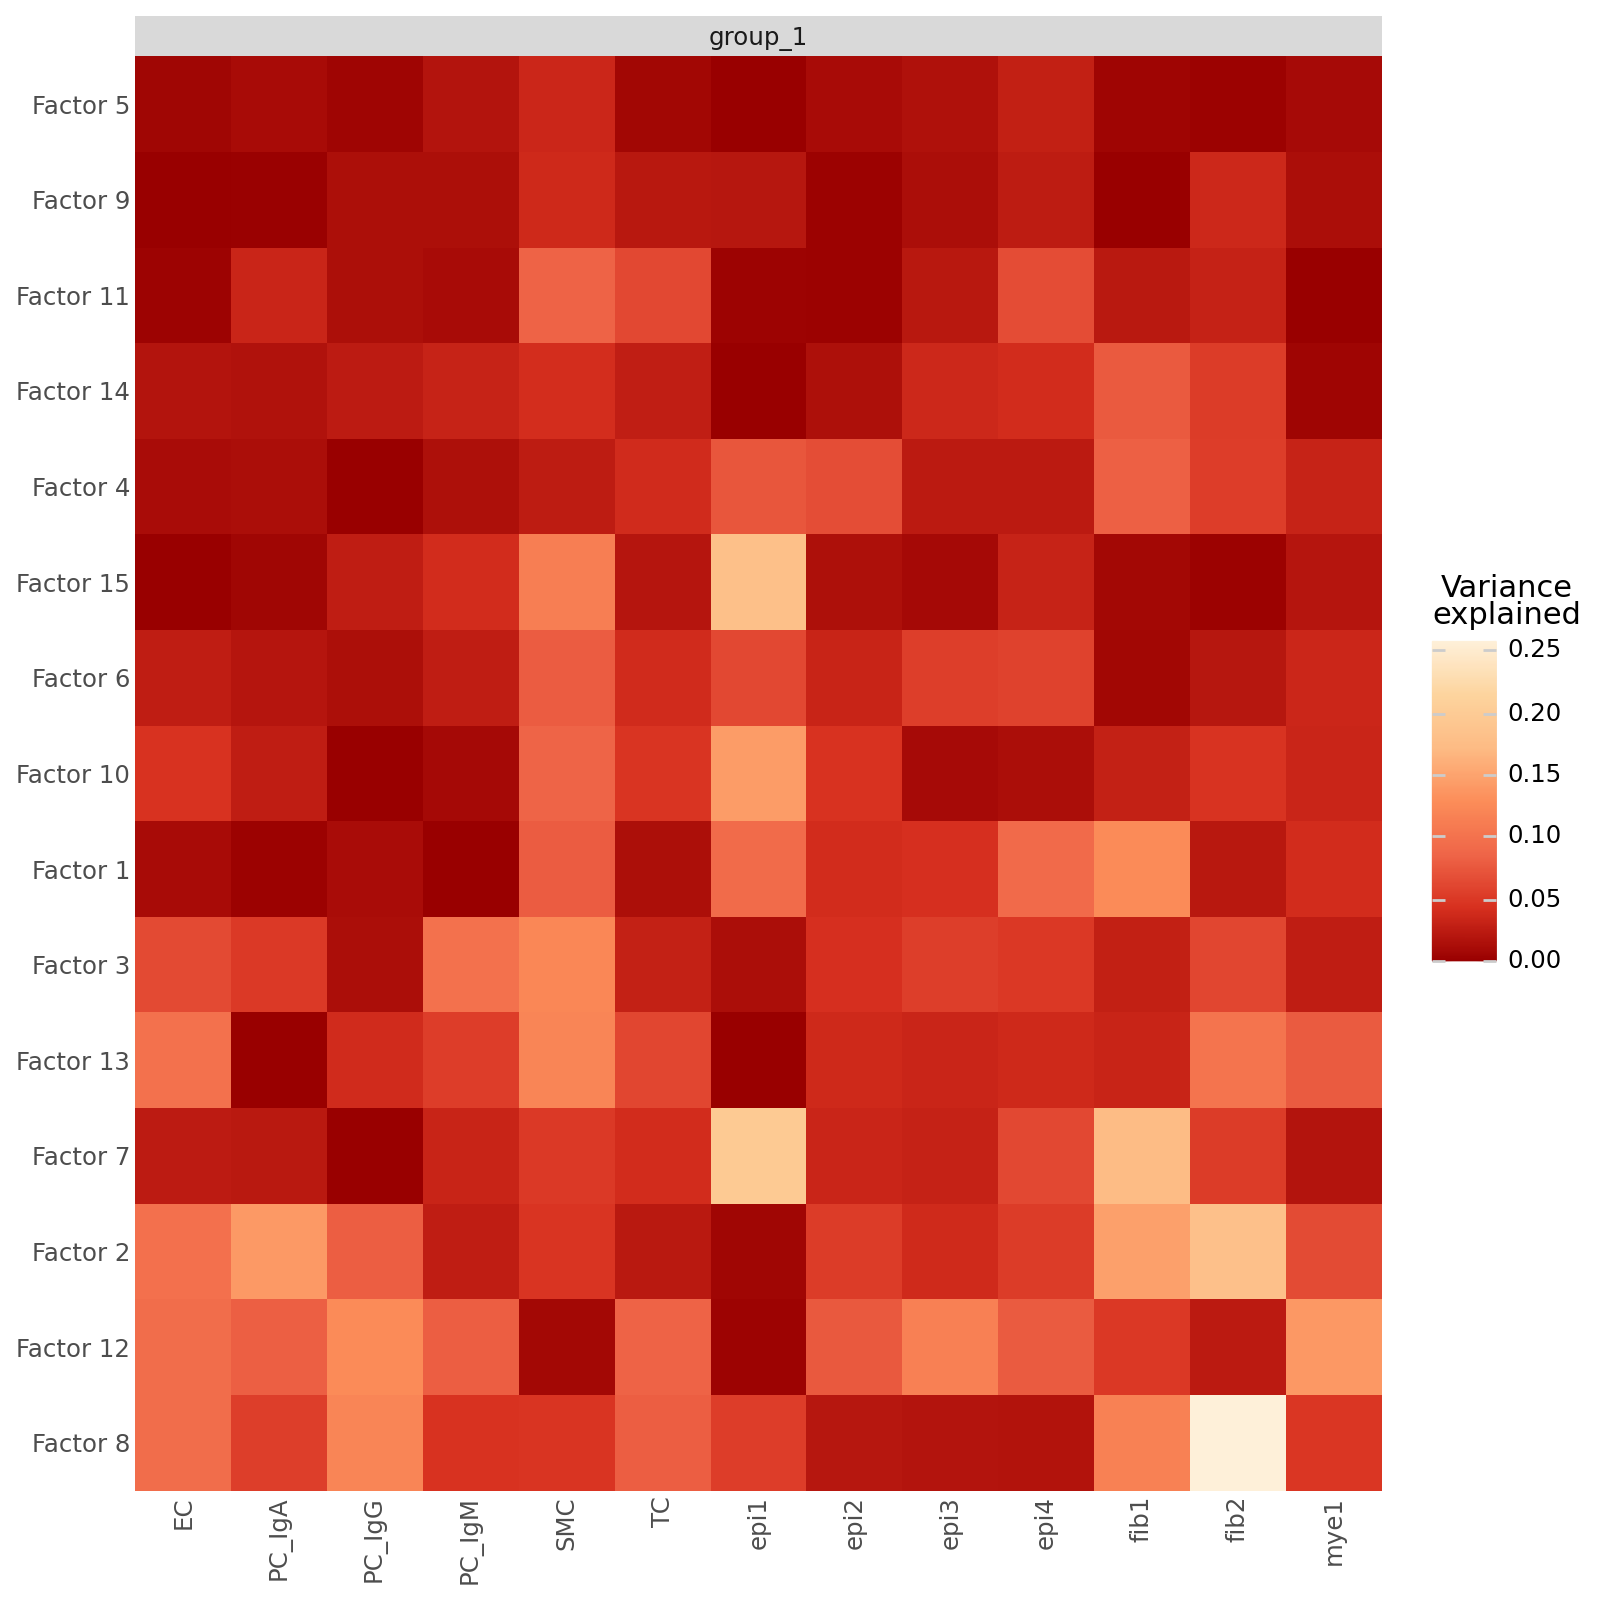

In [5]:
mfl.pl.variance_explained(model, figsize= (8,8))

## Average R2

In [6]:
print(model.get_r2(total=True))

         group_1
epi1    0.665444
epi2    0.473489
epi4    0.654125
epi3    0.495195
EC      0.687994
mye1    0.502070
fib2    0.742025
PC_IgG  0.643835
PC_IgA  0.606190
TC      0.603896
PC_IgM  0.478100
fib1    0.816798
SMC     0.756464


In [7]:
r2 = model.get_r2(total=True)
r2["group_1"].mean()

0.625048123396769

## Plot weight

In [8]:
weights_dict= model.get_weights()

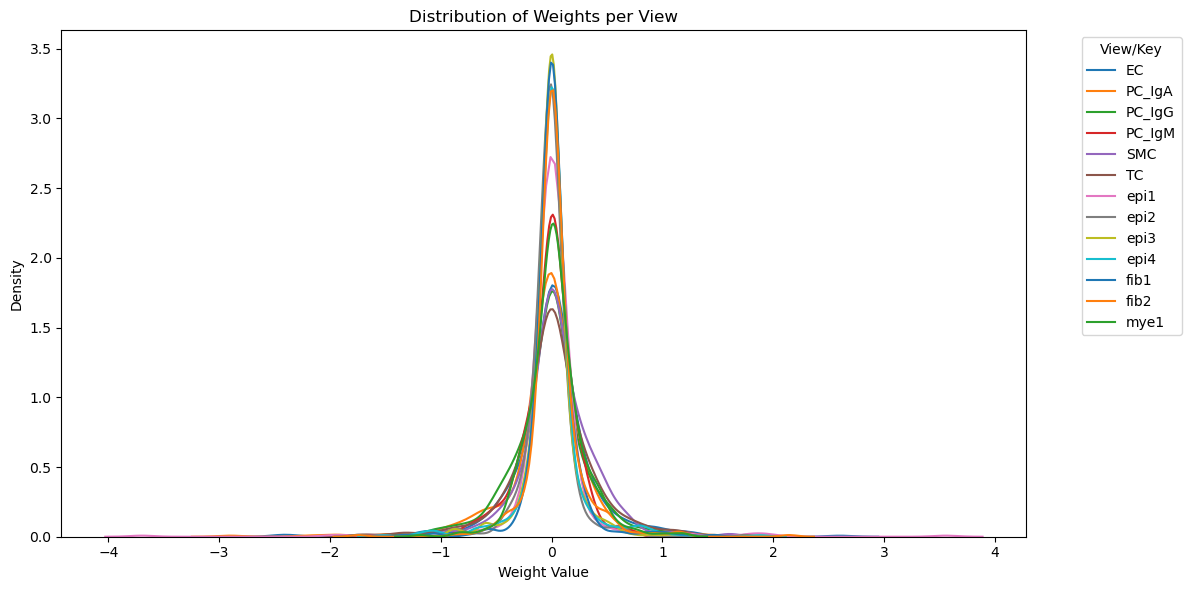

In [9]:
plt.figure(figsize=(12, 6))

# Loop through each view/key
for key, df in weights_dict.items():
    # Flatten all weights from that DataFrame into 1D array
    values = df.values.flatten()
    sns.kdeplot(values, label=key, fill=False)  # distribution curve

plt.title("Distribution of Weights per View")
plt.xlabel("Weight Value")
plt.ylabel("Density")
plt.legend(title="View/Key", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
mfl.pl.all_weights(model_gp, views=['fib2'], figsize=(8,8), show_featurenames=True)

NameError: name 'model_gp' is not defined

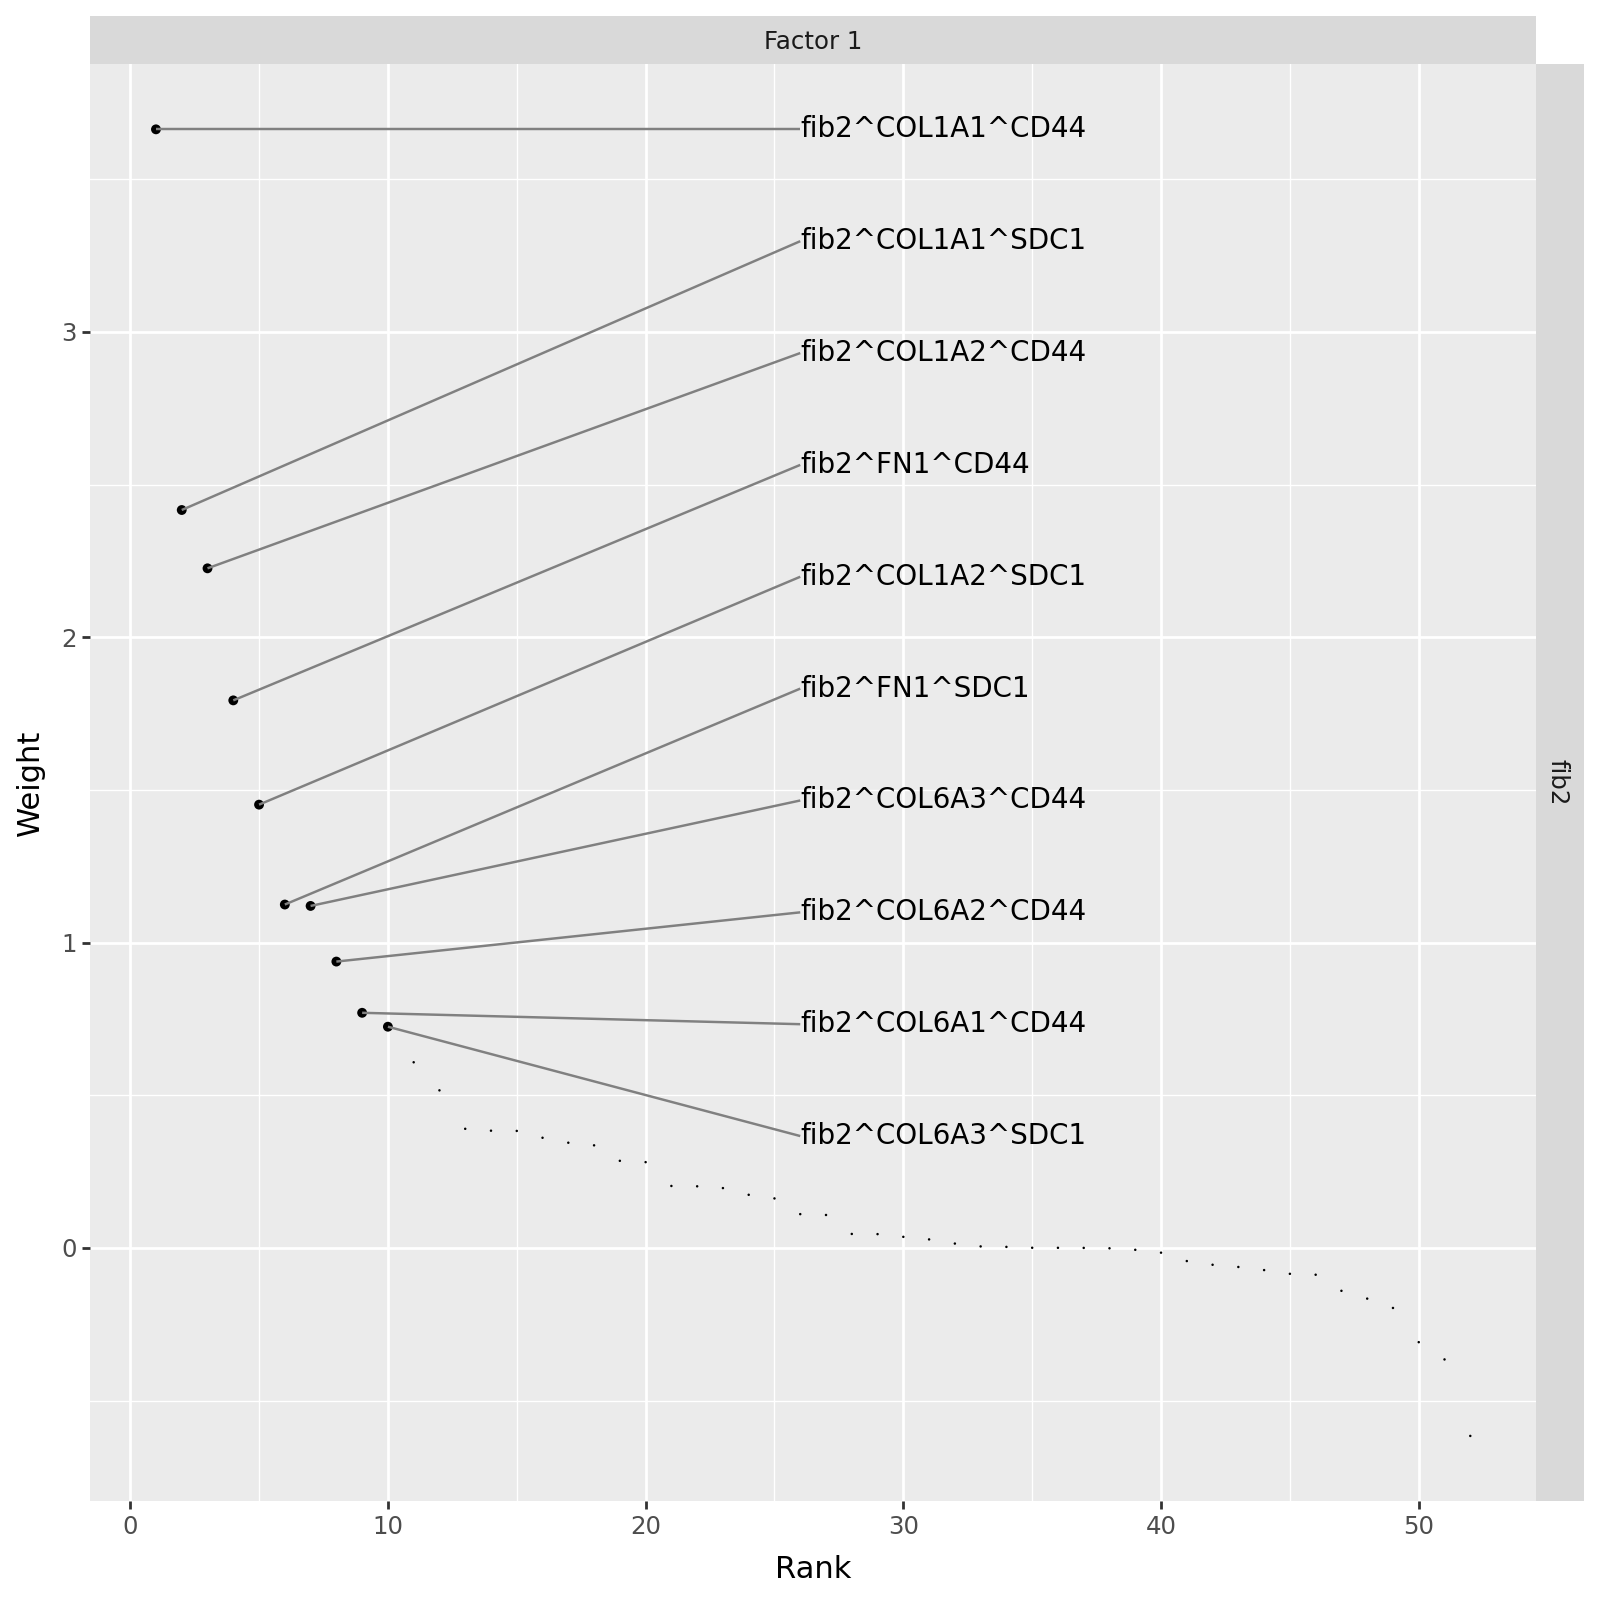

In [122]:
mfl.pl.weights(model, n_features=10, views=["fib2"], factors=1, pointsize=2, figsize=(8,8))

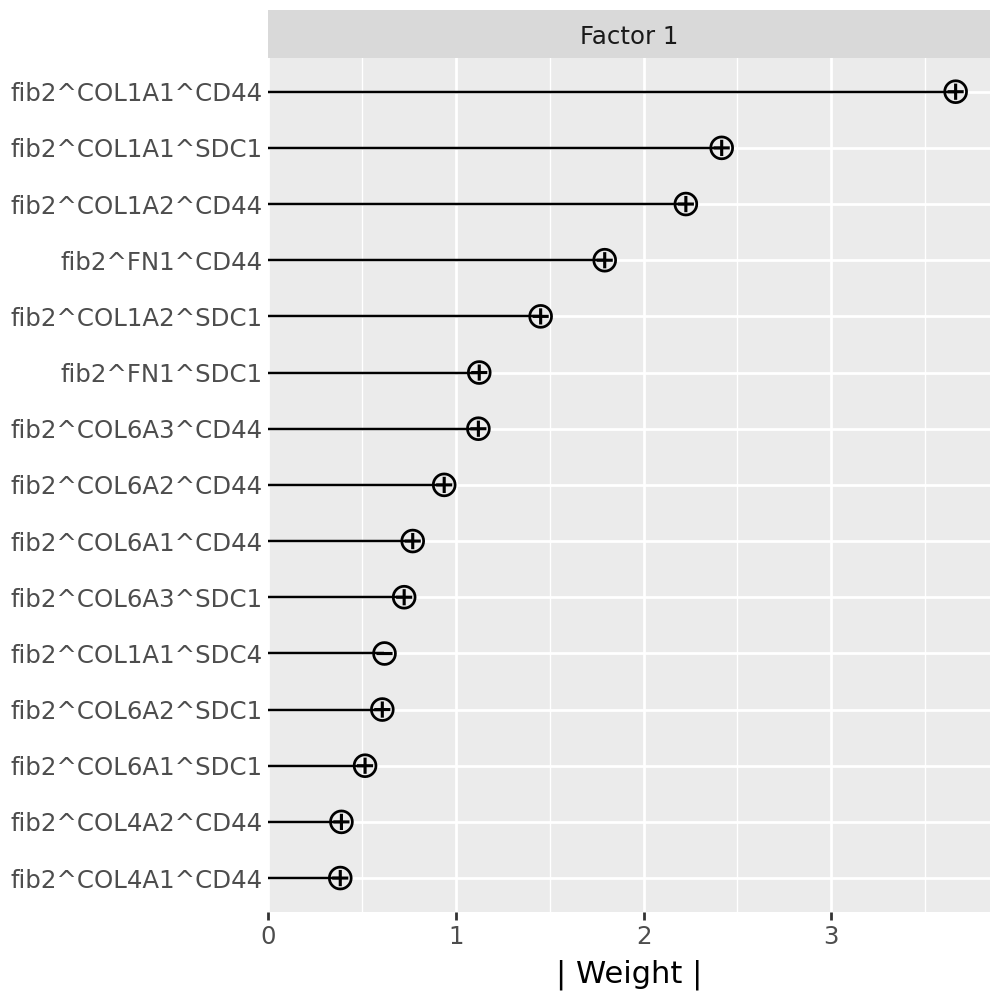

In [123]:
mfl.pl.top_weights(model, n_features=15, views="fib2", factors=1)

## Heatmap (view x LR)

In [26]:
from string import ascii_uppercase
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

In [27]:
weights = model.get_weights()

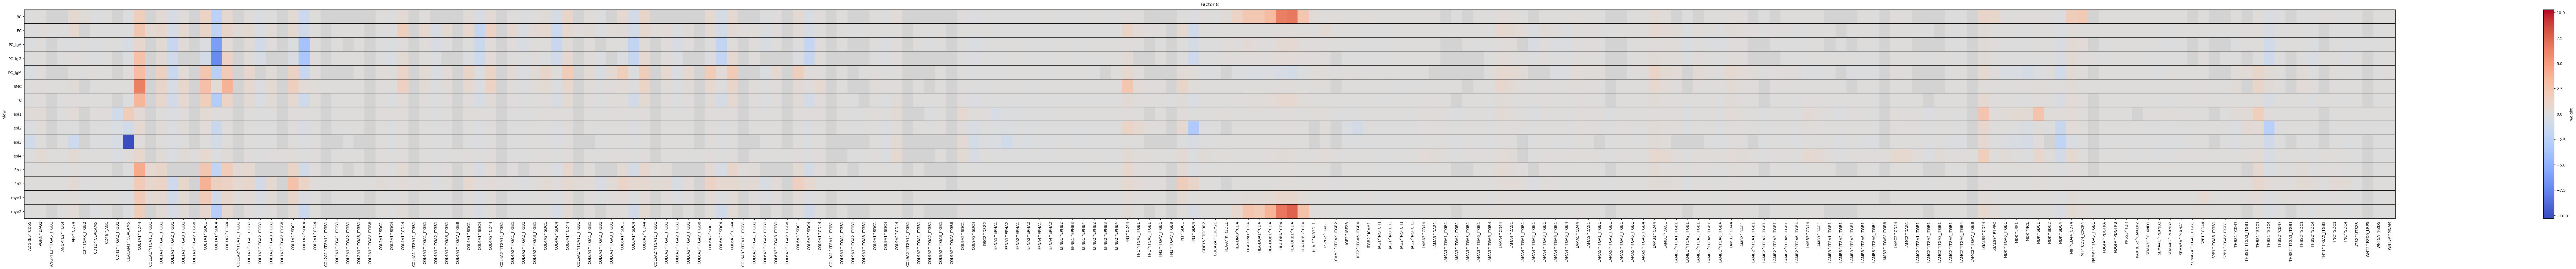

In [28]:
import re
from matplotlib.colors import TwoSlopeNorm

# choose the factor you want:
factor = 8 

def resolve_factor_label(df, factor):
    """
    Return the exact row label in df.index for a given factor selector.
    Accepts: 3, "3", "Factor 3", "factor 03", etc.
    """
    idx_map = {str(idx).strip().lower(): idx for idx in df.index}
    key = str(factor).strip().lower()
    # exact match first
    if key in idx_map:
        return idx_map[key]
    # otherwise pull the first integer and try "Factor {n}"
    m = re.search(r'\d+', key)
    if m:
        candidate = f"factor {int(m.group())}"
        if candidate in idx_map:
            return idx_map[candidate]
    raise KeyError(f"Couldn't find factor '{factor}'. Available: {list(df.index)}")

rows, labels = [], []
for view, df in weights.items():
    row_label = resolve_factor_label(df, factor)
    s = df.loc[row_label].copy()
    s.index = ['^'.join(c.split('^')[1:]) for c in s.index]  # drop prefix before first ^
    rows.append(s)
    labels.append(view)

# assemble matrix (align columns across views)
all_cols = sorted({c for s in rows for c in s.index})
X = pd.DataFrame([s.reindex(all_cols) for s in rows], index=labels)

plt.figure(figsize=(0.5*X.shape[1] + 2, 0.6*X.shape[0] + 1))

# zero-centered diverging colormap
v = np.nanmax(np.abs(X.values))
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)
cmap = plt.get_cmap('coolwarm').copy()
cmap.set_bad('lightgray')  # NaNs

im = plt.imshow(np.ma.masked_invalid(X.values),
                aspect='auto', interpolation='nearest',
                cmap=cmap, norm=norm)

plt.yticks(range(X.shape[0]), X.index)
plt.xticks(range(X.shape[1]), X.columns, rotation=90)
plt.ylabel("view")
plt.colorbar(im, label="weight")
for r in range(1, X.shape[0]):
    plt.axhline(r - 0.5, color='black', lw=1)
plt.title(f"Factor {factor}", pad=10)  # shows "Factor 3" if you passed 3
plt.tight_layout()
plt.show()


## Cluster by factor score

In [19]:
factors = model.get_factors()
factors = factors["group_1"]

In [20]:
factors

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
c_2_1_10,0.333916,-0.315262,-0.573310,-0.443494,-0.403955,0.141947,-0.458633,0.459915,0.239436,-0.222065,-0.084443,-0.158574,0.007544,-0.063854,-0.666016
c_2_1_23,0.430527,0.753774,0.017519,0.122604,-0.188202,-0.156491,-0.499249,0.375014,-0.434834,0.662691,-0.563854,0.413925,0.559207,-0.196186,0.376658
c_2_1_36,0.065326,-0.664161,-0.348328,0.096608,0.744977,-0.474559,0.045566,-0.915417,0.257220,0.883146,0.879347,0.992493,-0.034464,0.293946,-0.051913
c_2_1_53,-0.028412,-0.072786,0.143168,-0.165028,0.345179,0.165829,0.150065,-0.475551,0.208810,0.040943,0.621137,0.589604,-0.245309,0.248552,0.260592
c_2_1_54,-0.082144,0.571810,-0.765805,0.666684,-0.210583,-0.879201,0.566529,0.093013,-0.664605,-0.520278,-0.222330,-0.197350,0.059380,1.425279,-0.615809
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_2_113_2517,3.547652,-4.785507,3.149609,0.271981,-0.446445,-2.856942,3.722309,-0.070081,3.656296,1.900706,1.639529,0.417957,0.657871,1.563127,1.674821
c_2_114_1672,1.439015,0.766561,-0.578005,-1.005740,0.692156,1.468003,-0.890211,-2.953574,3.246482,2.849204,-1.507683,4.634545,-0.861945,0.428081,-1.111506
c_2_114_2063,2.735799,1.933304,-1.522052,-2.583351,2.603994,2.382865,-2.120337,-3.134858,3.557514,3.480528,-1.428717,5.410069,0.338596,1.005007,-1.225275
c_2_120_3044,3.774198,-5.001466,2.572893,-0.118930,-0.425281,-2.756665,3.527477,-0.661984,3.661125,1.533036,0.985007,1.257638,0.903512,0.814848,1.077044


### Load lrdata

In [23]:
data_path = Path("/g/stegle/aalsayah/repos/data/lrdata_processed")
lrdata = sc.read_h5ad(data_path/ "crc_221_lrdata.h5ad")

In [24]:
lv1 = lrdata.obs["lv1"]
lv2 = lrdata.obs["lv2"]
ist = lrdata.obs["ist"]
typ = lrdata.obs["typ"]

In [25]:
lv1 = lv1.loc[lv1.index.intersection(factors.index)]
lv1 = lv1.reindex(factors.index)
lv1.shape

(149506,)

### UMAP

In [29]:
import umap.umap_ as umap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Step 1: Standardize factors
scaler = StandardScaler()
scaled_data = scaler.fit_transform(factors)

# Step 2: Apply UMAP (2D)
reducer = umap.UMAP(n_neighbors=5, min_dist=0.1, random_state=42)
umap_result = reducer.fit_transform(scaled_data)

# Step 3: Put into dataframe with labels
df_umap = pd.DataFrame(umap_result, columns=['UMAP1', 'UMAP2'], index=factors.index)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


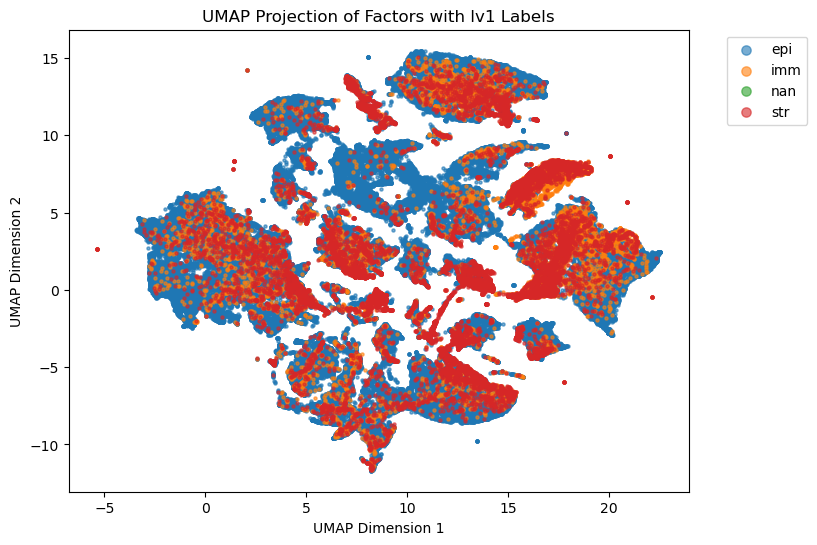

In [30]:
df_umap['Label'] = lv1.loc[factors.index].values

# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap['Label'].unique():
    subset = df_umap[df_umap['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors with lv1 Labels")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [31]:
import hdbscan

X_umap = df_umap[['UMAP1','UMAP2']].values
clusterer = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=10)

df_umap['Cluster'] = clusterer.fit_predict(X_umap)


/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


In [ ]:
plt.figure(figsize=(8,6))
for cl in df_umap['Cluster'].unique():
    subset = df_umap[df_umap['Cluster'] == cl]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=f"Cluster {cl}")

plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
plt.title("UMAP + Clustering")
plt.legend(markerscale=3, bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()